# Observables
Let $\tilde{S}_{iy}$ be the "raw" size of firm $i$ at year $y$, we then normalize it by dividing it with the average market size at that time
$$
S_{iy} = N_y \frac{\tilde{S}_{iy}}{\sum_i \tilde{S}_{iy}}
$$

then we define the growth rate as
$$
g_{iy} = \ln\left(\frac{S_{iy+1}}{S_{iy}}\right) = \ln(S_{iy+1}) - \ln(S_{iy}) =  \ln(N_{y+1}\tilde{S}_{iy+1}) - \ln(N_y \tilde{S}_{iy}) + \left[\ln\left(\sum_i \tilde{S}_{iy}\right) -  \ln\left(\sum_i \tilde{S}_{iy+1}\right) \right]
$$
from this the growth volatility is calculated using the adjusted mean absolute deviation
$$
\sigma_i = \sqrt{\frac{\pi}{2}} \frac{1}{T_i} \sum_y |g_{iy} - \bar{g}_i|
$$


In the paper "Firm-level production networks: what do we (really) know?" by Bacilieri et al. they describe the average degree in the network scaling as
$$
\bar{k} \sim N^{\eta}
$$
where $\eta \approx 0.13$

In [42]:
import numpy as np
import glv
from scipy.stats import truncnorm


# --- model parameters ---
N = 10000
C = 50
mu = 0.5
sigma = 0

# --- simulation parameters ---
tmax = 3
n_eval = 20          # time resolution; needs to be fine enough for yearly sampling

# --- observables parameters ---
year_length = 0.01     
n_bins = 25

year_times = np.arange(0, tmax + year_length, year_length)


In [43]:
n_realizations = 50

betas = []
all_bin_x = []
all_bin_y = []
all_degs = []
sol_plot = t_plot = None

for i in range(n_realizations):
    deg = np.round(np.random.exponential(scale=C, size=N)).astype(int)
    # deg = np.random.zipf(a=2.4, size=N)
    if np.sum(deg) % 2 != 0:
        deg[0] += 1
    all_degs.append(deg)
    A_r = glv.generate_matrix(deg, C, mu, sigma, True)

    # x0_r = np.random.uniform(0.5, 1.5, N)
    x0_r = truncnorm.rvs(0, 1000, size=N)
    sol_r, t_r = glv.simulate_glv(A_r, x0_r, tmax=tmax, n_eval=n_eval)

    if i == 0:
        sol_plot, t_plot = sol_r, t_r

    year_idx_r = np.searchsorted(t_r, year_times).clip(0, len(t_r) - 1)
    S_r = sol_r[year_idx_r]
    S_r = S_r / S_r.sum(axis=1, keepdims=True) * N
    g_r = np.diff(np.log(np.maximum(S_r, 1e-300)), axis=0)
    sigma_r = np.sqrt(np.pi / 2) * np.abs(g_r - g_r.mean(axis=0)).mean(axis=0)

    avg_size_r = S_r.mean(axis=0)
    bin_edges_r = np.percentile(avg_size_r, np.linspace(0, 100, n_bins + 1))
    bin_idx_r = np.digitize(avg_size_r, bin_edges_r[1:-1])
    bin_x_r = np.array([avg_size_r[bin_idx_r == b].mean() for b in range(n_bins)])
    bin_y_r = np.array([sigma_r[bin_idx_r == b].mean() for b in range(n_bins)])

    all_bin_x.append(bin_x_r)
    all_bin_y.append(bin_y_r)

    slope_r, _ = np.polyfit(np.log(bin_x_r), np.log(bin_y_r), 1)
    betas.append(slope_r)

betas = np.array(betas)
print(f"β  mean : {betas.mean():.4f}")
print(f"β  std  : {betas.std():.4f}")
print(f"β  values: {np.round(betas, 3)}")

β  mean : -0.1228
β  std  : 0.0115
β  values: [-0.129 -0.129 -0.126 -0.125 -0.128 -0.113 -0.143 -0.119 -0.14  -0.117
 -0.125 -0.11  -0.13  -0.142 -0.13  -0.118 -0.12  -0.131 -0.125 -0.111
 -0.103 -0.125 -0.135 -0.133 -0.128 -0.113 -0.121 -0.132 -0.114 -0.122
 -0.118 -0.13  -0.106 -0.104 -0.131 -0.128 -0.109 -0.122 -0.123 -0.115
 -0.113 -0.15  -0.12  -0.11  -0.098 -0.14  -0.097 -0.119 -0.132 -0.136]


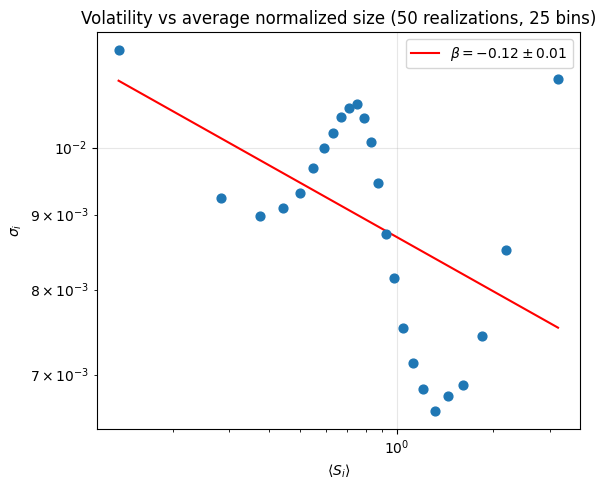

In [44]:
import matplotlib.pyplot as plt

# average binned data across realizations (bins are percentile-based so x values differ — average in log space)
mean_bin_x = np.exp(np.mean(np.log(all_bin_x), axis=0))
mean_bin_y = np.exp(np.mean(np.log(all_bin_y), axis=0))

beta_mean = betas.mean()
intercept_mean = np.mean(np.log(all_bin_y) - beta_mean * np.log(all_bin_x))
x_line = np.logspace(np.log10(mean_bin_x.min()), np.log10(mean_bin_x.max()), 200)
y_line = np.exp(intercept_mean) * x_line ** beta_mean

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(mean_bin_x, mean_bin_y, s=40, zorder=3)
ax.plot(x_line, y_line, color="red", lw=1.5, label=rf"$\beta = {beta_mean:.2f} \pm {betas.std():.2f}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\langle S_i \rangle$")
ax.set_ylabel(r"$\sigma_i$")
ax.set_title(f"Volatility vs average normalized size ({n_realizations} realizations, {n_bins} bins)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


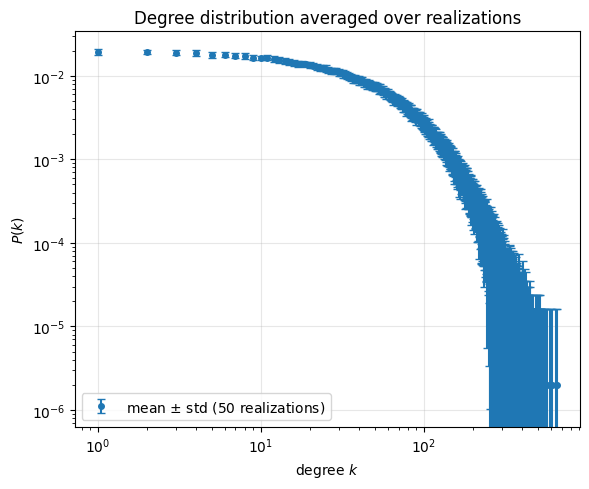

In [45]:
# Degree distribution averaged over realizations
k_max = max(d.max() for d in all_degs)
k_vals = np.arange(1, k_max + 1)

counts = np.zeros((n_realizations, k_max), dtype=float)
for i, deg in enumerate(all_degs):
    for k, c in zip(*np.unique(deg, return_counts=True)):
        if k >= 1:
            counts[i, k - 1] = c / len(deg)

mean_pk = counts.mean(axis=0)
std_pk = counts.std(axis=0)

# keep only degrees with non-zero mean
mask = mean_pk > 0
k_plot = k_vals[mask]
pk_plot = mean_pk[mask]
pk_std  = std_pk[mask]

fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(k_plot, pk_plot, yerr=pk_std, fmt="o", ms=4, capsize=3,
            label=rf"mean $\pm$ std ({n_realizations} realizations)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"degree $k$")
ax.set_ylabel(r"$P(k)$")
ax.set_title("Degree distribution averaged over realizations")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

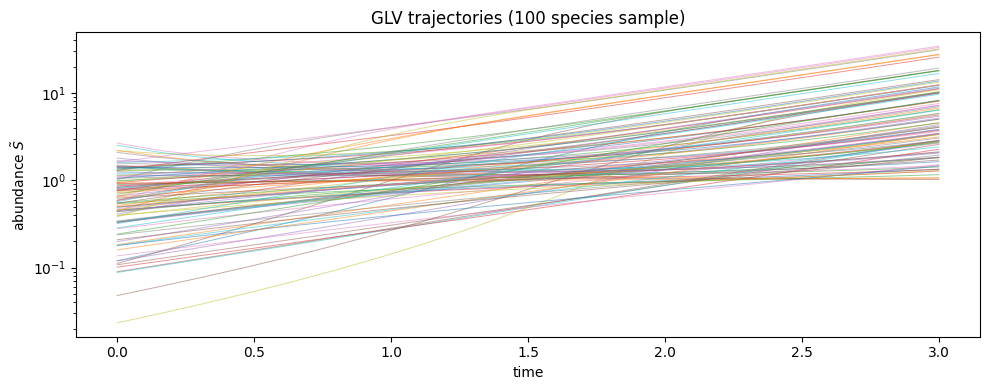

In [46]:
import matplotlib.pyplot as plt

sample_idx = np.random.choice(N, size=min(100, N), replace=False)

fig, ax = plt.subplots(figsize=(10, 4))
for i in sample_idx:
    ax.plot(t_plot, sol_plot[:, i], lw=0.7, alpha=0.5)

ax.set_xlabel("time")
ax.set_ylabel("abundance $\\tilde{S}$")
ax.set_yscale("log")
ax.set_title("GLV trajectories (100 species sample)")
plt.tight_layout()
plt.show()

![](images/volatility_vs_size_bm.png)